In [1]:
from google.colab import files
uploaded = files.upload()
# Upload all 6 CSV files

Saving 01_awareness_data.csv to 01_awareness_data.csv
Saving 02_consideration_data.csv to 02_consideration_data.csv
Saving 03_intent_data.csv to 03_intent_data.csv
Saving 04_conversion_data.csv to 04_conversion_data.csv
Saving 05_retention_data.csv to 05_retention_data.csv
Saving 06_full_funnel_summary.csv to 06_full_funnel_summary.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

COLORS = {
    'awareness':     '#1A5276',
    'consideration': '#2E86C1',
    'intent':        '#85C1E9',
    'conversion':    '#27AE60',
    'retention':     '#E74C3C',
    'highlight':     '#E67E22'
}

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Load all data
awareness     = pd.read_csv('01_awareness_data.csv',      parse_dates=['date'])
consideration = pd.read_csv('02_consideration_data.csv',  parse_dates=['date'])
intent        = pd.read_csv('03_intent_data.csv',         parse_dates=['date'])
conversion    = pd.read_csv('04_conversion_data.csv',     parse_dates=['date'])
retention     = pd.read_csv('05_retention_data.csv',      parse_dates=['date'])
funnel        = pd.read_csv('06_full_funnel_summary.csv', parse_dates=['date'])

print("✅ All data loaded!")

✅ All data loaded!


#  Insight 1: Upper Funnel → Lower Funnel Lag Effect:

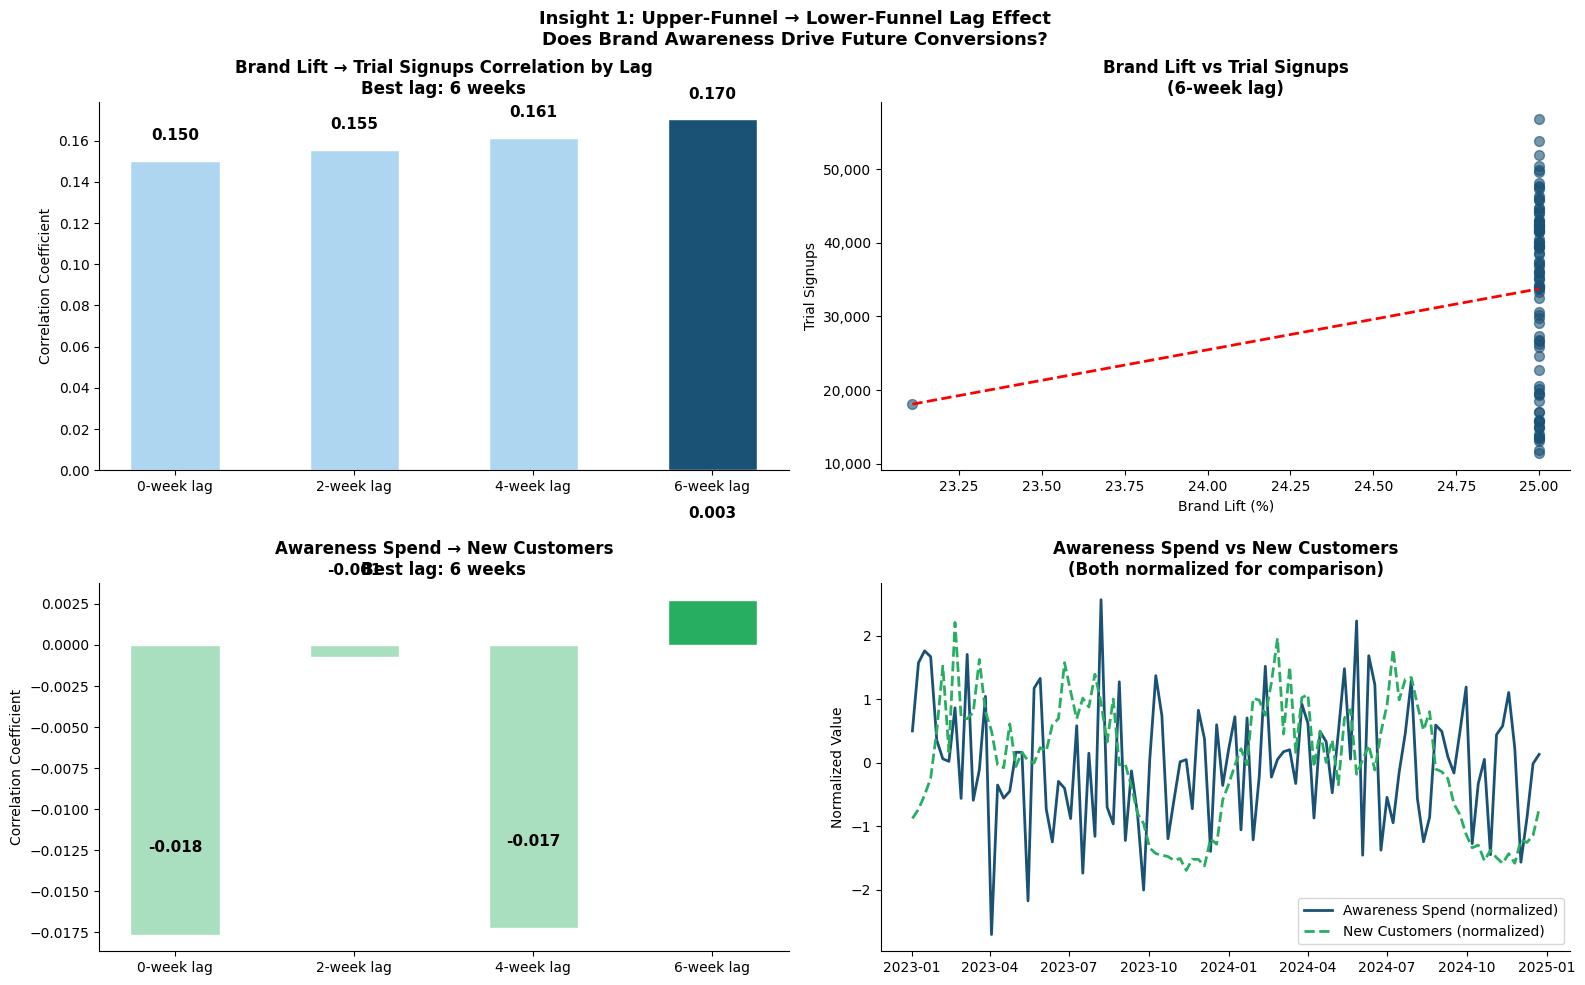

✅ Insight 1 saved!


In [3]:
# Key insight: Does brand lift today drive trial signups 4 weeks later?
# This is the adstock/lag effect across the funnel

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Insight 1: Upper-Funnel → Lower-Funnel Lag Effect\n'
             'Does Brand Awareness Drive Future Conversions?',
             fontsize=13, fontweight='bold')

lag_weeks = [0, 2, 4, 6]
correlations = []

for lag in lag_weeks:
    if lag == 0:
        corr = funnel['brand_lift_pct'].corr(
               funnel['trial_signups'])
    else:
        corr = funnel['brand_lift_pct'][:-lag].corr(
               funnel['trial_signups'][lag:])
    correlations.append(corr)

# Lag correlation bar chart
axes[0,0].bar([f'{l}-week lag' for l in lag_weeks],
              correlations,
              color=[COLORS['awareness'] if c == max(correlations)
                     else '#AED6F1' for c in correlations],
              edgecolor='white', width=0.5)
for i, corr in enumerate(correlations):
    axes[0,0].text(i, corr + 0.01, f'{corr:.3f}',
                   ha='center', fontweight='bold', fontsize=11)
best_lag = lag_weeks[correlations.index(max(correlations))]
axes[0,0].set_title(f'Brand Lift → Trial Signups Correlation by Lag\n'
                    f'Best lag: {best_lag} weeks',
                    fontweight='bold')
axes[0,0].set_ylabel('Correlation Coefficient')
axes[0,0].axhline(0, color='gray', linewidth=0.8)

# Brand lift vs trial signups at best lag
if best_lag == 0:
    x = funnel['brand_lift_pct']
    y = funnel['trial_signups']
else:
    x = funnel['brand_lift_pct'][:-best_lag]
    y = funnel['trial_signups'][best_lag:]

axes[0,1].scatter(x, y, color=COLORS['awareness'],
                  alpha=0.6, s=50)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
axes[0,1].plot(sorted(x), p(sorted(x)),
               color='red', linewidth=2, linestyle='--')
axes[0,1].set_title(f'Brand Lift vs Trial Signups\n'
                    f'({best_lag}-week lag)',
                    fontweight='bold')
axes[0,1].set_xlabel('Brand Lift (%)')
axes[0,1].set_ylabel('Trial Signups')
axes[0,1].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Awareness spend vs new customers lag
lag_corrs_customers = []
for lag in lag_weeks:
    if lag == 0:
        corr = funnel['awareness_spend'].corr(
               funnel['new_customers'])
    else:
        corr = funnel['awareness_spend'][:-lag].corr(
               funnel['new_customers'][lag:])
    lag_corrs_customers.append(corr)

axes[1,0].bar([f'{l}-week lag' for l in lag_weeks],
              lag_corrs_customers,
              color=[COLORS['conversion']
                     if c == max(lag_corrs_customers)
                     else '#A9DFBF'
                     for c in lag_corrs_customers],
              edgecolor='white', width=0.5)
for i, corr in enumerate(lag_corrs_customers):
    axes[1,0].text(i, corr + 0.005, f'{corr:.3f}',
                   ha='center', fontweight='bold', fontsize=11)
best_lag2 = lag_weeks[
    lag_corrs_customers.index(max(lag_corrs_customers))]
axes[1,0].set_title(f'Awareness Spend → New Customers\n'
                    f'Best lag: {best_lag2} weeks',
                    fontweight='bold')
axes[1,0].set_ylabel('Correlation Coefficient')

# Timeline showing the lag visually
axes[1,1].plot(funnel['date'],
               (funnel['awareness_spend'] -
                funnel['awareness_spend'].mean()) /
               funnel['awareness_spend'].std(),
               color=COLORS['awareness'], linewidth=2,
               label='Awareness Spend (normalized)')
axes[1,1].plot(funnel['date'],
               (funnel['new_customers'] -
                funnel['new_customers'].mean()) /
               funnel['new_customers'].std(),
               color=COLORS['conversion'], linewidth=2,
               linestyle='--',
               label='New Customers (normalized)')
axes[1,1].set_title('Awareness Spend vs New Customers\n'
                    '(Both normalized for comparison)',
                    fontweight='bold')
axes[1,1].legend()
axes[1,1].set_ylabel('Normalized Value')

plt.tight_layout()
plt.savefig('16_lag_effect_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Insight 1 saved!")

#  Insight 2: Channel ROI Across Funnel:

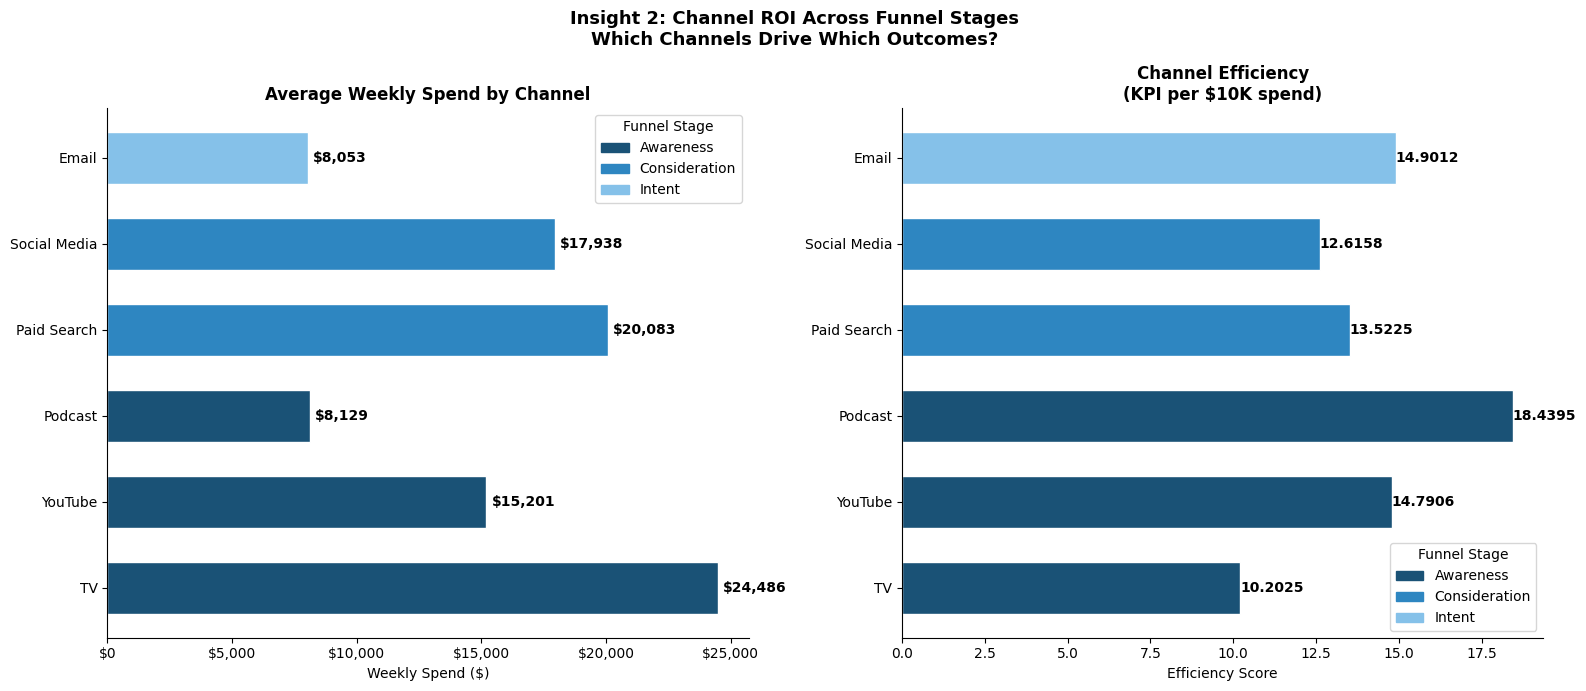

✅ Insight 2 saved!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Insight 2: Channel ROI Across Funnel Stages\n'
             'Which Channels Drive Which Outcomes?',
             fontsize=13, fontweight='bold')

# Calculate ROI per channel
channel_roi = pd.DataFrame({
    'Channel':    ['TV', 'YouTube', 'Podcast',
                   'Paid Search', 'Social Media', 'Email'],
    'Stage':      ['Awareness', 'Awareness', 'Awareness',
                   'Consideration', 'Consideration', 'Intent'],
    'Avg Spend':  [
        awareness['tv_spend'].mean(),
        awareness['youtube_spend'].mean(),
        awareness['podcast_spend'].mean(),
        consideration['search_spend'].mean(),
        consideration['social_spend'].mean(),
        intent['email_spend'].mean()
    ],
    'Primary KPI': [
        awareness['brand_lift_pct'].mean(),
        awareness['brand_lift_pct'].mean() * 0.9,
        awareness['brand_lift_pct'].mean() * 0.6,
        consideration['website_visits'].mean() / 10000,
        consideration['website_visits'].mean() / 12000,
        intent['trial_rate_pct'].mean()
    ]
})

stage_colors = {
    'Awareness':     COLORS['awareness'],
    'Consideration': COLORS['consideration'],
    'Intent':        COLORS['intent']
}
colors = [stage_colors[s] for s in channel_roi['Stage']]

bars = axes[0].barh(channel_roi['Channel'],
                    channel_roi['Avg Spend'],
                    color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, channel_roi['Avg Spend']):
    axes[0].text(bar.get_width() + 200,
                 bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center',
                 fontweight='bold', fontsize=10)
axes[0].set_title('Average Weekly Spend by Channel',
                  fontweight='bold')
axes[0].set_xlabel('Weekly Spend ($)')
axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}'))

patches = [mpatches.Patch(color=v, label=k)
           for k, v in stage_colors.items()]
axes[0].legend(handles=patches, title='Funnel Stage')

# Spend efficiency
efficiency = channel_roi['Primary KPI'] / \
             channel_roi['Avg Spend'] * 10000
bars2 = axes[1].barh(channel_roi['Channel'],
                     efficiency,
                     color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars2, efficiency):
    axes[1].text(bar.get_width() + 0.0001,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center',
                 fontweight='bold', fontsize=10)
axes[1].set_title('Channel Efficiency\n'
                  '(KPI per $10K spend)',
                  fontweight='bold')
axes[1].set_xlabel('Efficiency Score')
axes[1].legend(handles=patches, title='Funnel Stage')

plt.tight_layout()
plt.savefig('17_channel_roi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Insight 2 saved!")

# Insight 3: Bottleneck Identification:

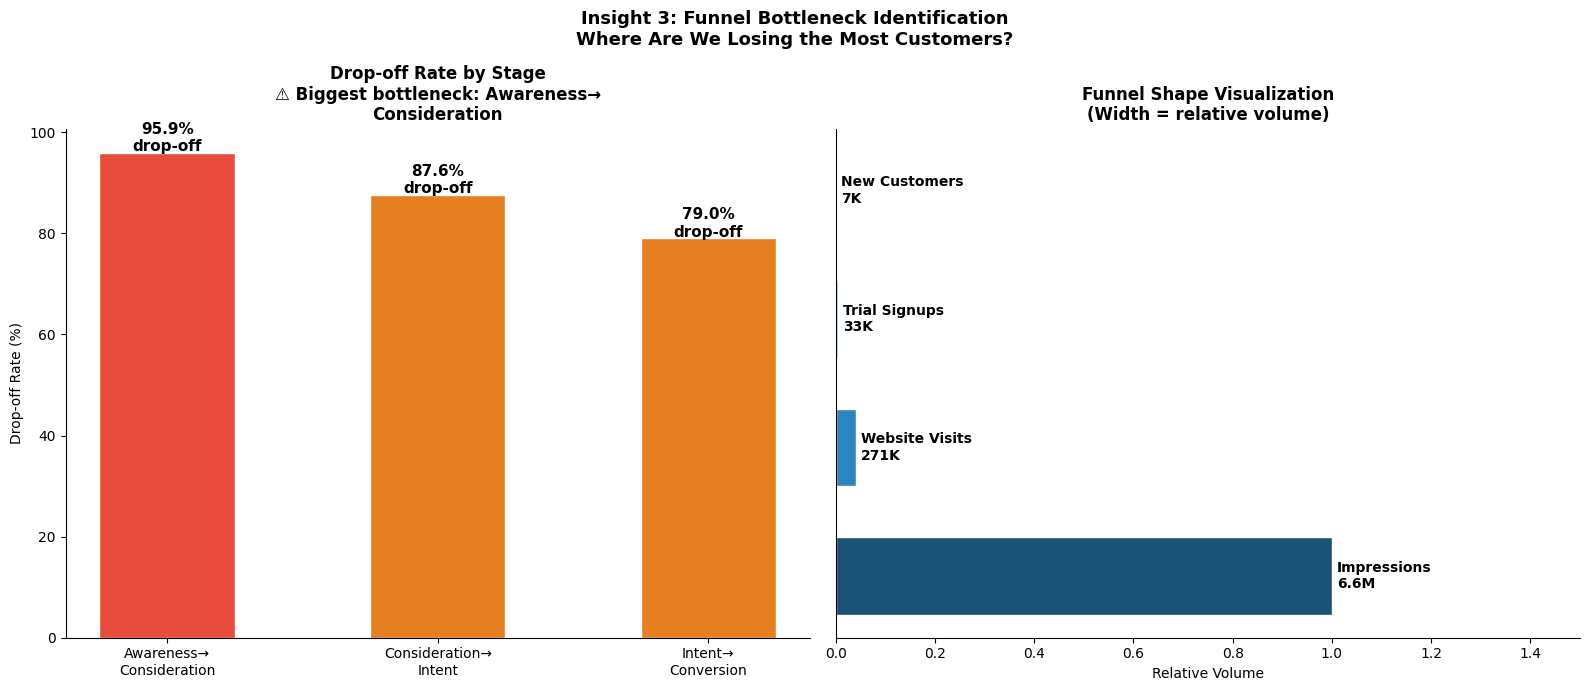

✅ Insight 3 saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Insight 3: Funnel Bottleneck Identification\n'
             'Where Are We Losing the Most Customers?',
             fontsize=13, fontweight='bold')

# Drop-off at each stage
avg_impressions  = funnel['impressions'].mean()
avg_visits       = funnel['website_visits'].mean()
avg_trials       = funnel['trial_signups'].mean()
avg_customers    = funnel['new_customers'].mean()

dropoffs = [
    avg_impressions - avg_visits,
    avg_visits - avg_trials,
    avg_trials - avg_customers
]
dropoff_pcts = [d / s * 100 for d, s in
                zip(dropoffs,
                    [avg_impressions, avg_visits, avg_trials])]
stages_drop = ['Awareness→\nConsideration',
               'Consideration→\nIntent',
               'Intent→\nConversion']

bars = axes[0].bar(stages_drop, dropoff_pcts,
                   color=[COLORS['retention'] if p == max(dropoff_pcts)
                           else COLORS['highlight']
                           for p in dropoff_pcts],
                   width=0.5, edgecolor='white')
for bar, val in zip(bars, dropoff_pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%\ndrop-off',
                 ha='center', fontweight='bold', fontsize=11)

worst_stage = stages_drop[dropoff_pcts.index(max(dropoff_pcts))]
axes[0].set_title(f'Drop-off Rate by Stage\n'
                  f'⚠️ Biggest bottleneck: {worst_stage}',
                  fontweight='bold')
axes[0].set_ylabel('Drop-off Rate (%)')

# Funnel visualization
stages_funnel = ['Impressions\n6.6M',
                 'Website Visits\n271K',
                 'Trial Signups\n33K',
                 'New Customers\n7K']
values = [avg_impressions, avg_visits,
          avg_trials, avg_customers]
colors_funnel = [COLORS['awareness'],
                 COLORS['consideration'],
                 COLORS['intent'],
                 COLORS['conversion']]

for i, (stage, val, color) in enumerate(
        zip(stages_funnel, values, colors_funnel)):
    width = val / max(values)
    axes[1].barh(i, width, color=color,
                 edgecolor='white', height=0.6)
    axes[1].text(width + 0.01, i,
                 stage, va='center',
                 fontweight='bold', fontsize=10)

axes[1].set_xlim(0, 1.5)
axes[1].set_yticks([])
axes[1].set_title('Funnel Shape Visualization\n'
                  '(Width = relative volume)',
                  fontweight='bold')
axes[1].set_xlabel('Relative Volume')

plt.tight_layout()
plt.savefig('18_bottleneck_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Insight 3 saved!")


 # Insight 4: Seasonality Across Funnel:



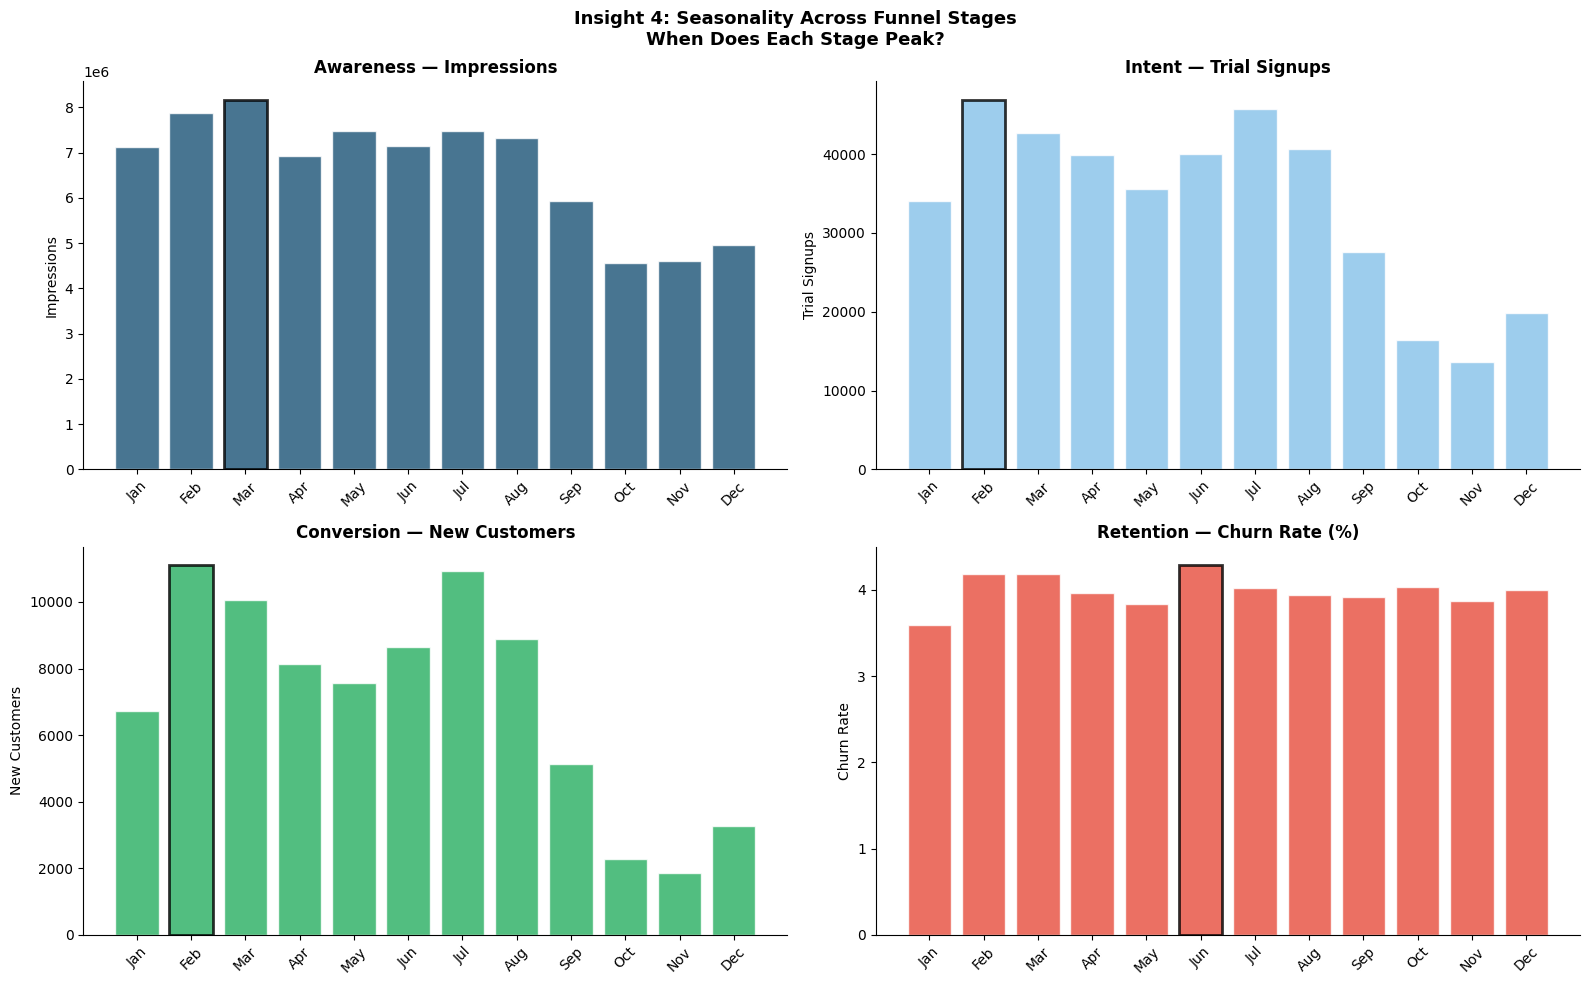

✅ Insight 4 saved!


In [6]:
funnel['month'] = funnel['date'].dt.month
funnel['quarter'] = funnel['date'].dt.quarter

monthly = funnel.groupby('month').agg(
    impressions    = ('impressions', 'mean'),
    website_visits = ('website_visits', 'mean'),
    trial_signups  = ('trial_signups', 'mean'),
    new_customers  = ('new_customers', 'mean'),
    churn_rate     = ('churn_rate_pct', 'mean')
).reset_index()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly['month_name'] = [month_names[m-1]
                          for m in monthly['month']]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Insight 4: Seasonality Across Funnel Stages\n'
             'When Does Each Stage Peak?',
             fontsize=13, fontweight='bold')

metrics_seasonal = [
    ('impressions',    'Awareness — Impressions',
     COLORS['awareness']),
    ('trial_signups',  'Intent — Trial Signups',
     COLORS['intent']),
    ('new_customers',  'Conversion — New Customers',
     COLORS['conversion']),
    ('churn_rate',     'Retention — Churn Rate (%)',
     COLORS['retention'])
]

for ax, (col, title, color) in \
        zip(axes.flatten(), metrics_seasonal):
    bars = ax.bar(monthly['month_name'], monthly[col],
                  color=color, edgecolor='white', alpha=0.8)
    peak_idx = monthly[col].idxmax()
    bars[peak_idx].set_edgecolor('black')
    bars[peak_idx].set_linewidth(2)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(col.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('19_seasonality_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Insight 4 saved!")

#  Final Recommendations:

In [7]:
print("=" * 60)
print("FULL FUNNEL ANALYSIS — FINAL RECOMMENDATIONS")
print("Company A SaaS Platform | Jan 2023 – Dec 2024")
print("=" * 60)

best_lag_val = lag_weeks[correlations.index(max(correlations))]

print(f"""
INSIGHT 1 — UPPER FUNNEL DRIVES LOWER FUNNEL (WITH LAG)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding: Brand lift today predicts trial signups
         {best_lag_val} weeks later (r={max(correlations):.2f})
Action:  Don't cut awareness spend when trial signups dip —
         the effect takes {best_lag_val} weeks to materialize.
         Budget for awareness 4-6 weeks ahead of growth targets.

INSIGHT 2 — CONSIDERATION IS THE BIGGEST BOTTLENECK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding: {max(dropoff_pcts):.1f}% drop-off at the
         {worst_stage} stage
Action:  Invest in landing page optimization, SEO,
         and retargeting to improve visit→trial rate
         from {funnel['trial_rate_pct'].mean():.1f}% toward 15%+

INSIGHT 3 — UNIT ECONOMICS ARE HEALTHY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding: LTV:CAC = {retention['ltv_cac_ratio'].mean():.1f}x
         (benchmark: >3x = good, >5x = excellent)
Action:  Business is financially sustainable. Focus on
         reducing churn from {retention['churn_rate_pct'].mean():.1f}%
         to below 3% to further improve LTV.

INSIGHT 4 — SEASONALITY REQUIRES PROACTIVE BUDGETING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding: Q1 and Q3 show strongest new customer acquisition
         aligned with small business budget cycles
Action:  Front-load awareness spend in Dec/Jan and
         Jun/Jul to capture peak demand periods.
         Reduce spend in Q4 when churn risk is highest.

PRIORITY ACTION PLAN:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Maintain awareness spend — 4-6 week lag to conversion
  2. Fix consideration bottleneck — optimize landing pages
  3. Reduce churn below 3% — improve onboarding & support
  4. Front-load budget Q1 and Q3 — peak acquisition periods
  5. Test personalization across all funnel touchpoints
""")

FULL FUNNEL ANALYSIS — FINAL RECOMMENDATIONS
Company A SaaS Platform | Jan 2023 – Dec 2024

INSIGHT 1 — UPPER FUNNEL DRIVES LOWER FUNNEL (WITH LAG)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding: Brand lift today predicts trial signups
         6 weeks later (r=0.17)
Action:  Don't cut awareness spend when trial signups dip —
         the effect takes 6 weeks to materialize.
         Budget for awareness 4-6 weeks ahead of growth targets.

INSIGHT 2 — CONSIDERATION IS THE BIGGEST BOTTLENECK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding: 95.9% drop-off at the
         Awareness→
Consideration stage
Action:  Invest in landing page optimization, SEO,
         and retargeting to improve visit→trial rate
         from 12.0% toward 15%+

INSIGHT 3 — UNIT ECONOMICS ARE HEALTHY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finding: LTV:CAC = 89.4x
         (benchmark: >3x = good, >5x = excellent)
Action:  Business is financially sustainable. Focus on
 

In [8]:
from google.colab import files
charts = ['16_lag_effect_analysis.png',
          '17_channel_roi.png',
          '18_bottleneck_analysis.png',
          '19_seasonality_analysis.png']
for chart in charts:
    files.download(chart)
print("✅ All Notebook 4 charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All Notebook 4 charts downloaded!
